# Experiment 5: Decision Tree and Random Forest — A Comparative Classification Study

**Course:** ICS1512 — Machine Learning Algorithms Laboratory
**Student:** Hemnath D
**Register Number:** 3122247001022
**Submission Date:** 16 August 2026
**GitHub:** https://github.com/hemnathd12/ml-assignments

**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC) — 569 samples, 30 numerical features, 2 classes (Malignant / Benign)

This notebook implements and compares a Decision Tree classifier and a Random Forest ensemble, using 5-fold cross-validation for hyperparameter selection, on the WDBC dataset.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV,
                                      cross_val_score, learning_curve)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, auc, precision_recall_curve,
                              average_precision_score, ConfusionMatrixDisplay)

RNG = 42
DPI = 600

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.autolayout": True,
})
sns.set_style("whitegrid")

## 2. Load Dataset

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y_raw = data.target_names[data.target]  # 'malignant' / 'benign'

le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_
print("Classes:", class_names, "-> encoding:", dict(zip(class_names, le.transform(class_names))))

df = X.copy()
df["diagnosis"] = y_raw

print("Dataset shape:", df.shape)
print("Missing values total:", df.isnull().sum().sum())
df.head()

Classes: ['benign' 'malignant'] -> encoding: {np.str_('benign'): np.int64(0), np.str_('malignant'): np.int64(1)}
Dataset shape: (569, 31)
Missing values total: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


In [3]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## 3. Exploratory Data Analysis

### 3.1 Class Distribution

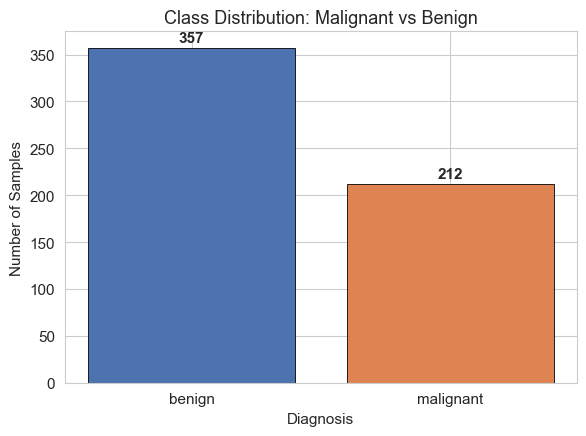

In [4]:
fig, ax = plt.subplots(figsize=(6, 4.5))
counts = df["diagnosis"].value_counts()
colors = ["#4C72B0", "#DD8452"]
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="black", linewidth=0.6)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 3, str(int(b.get_height())),
            ha="center", va="bottom", fontweight="bold")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Number of Samples")
ax.set_title("Class Distribution: Malignant vs Benign")
plt.savefig("class_distribution.png", dpi=DPI)
plt.show()

**Inference:** The dataset is moderately imbalanced (357 benign vs. 212 malignant, ~1.7:1), which motivates stratified splitting/cross-validation and the use of precision/recall/F1 alongside accuracy.

### 3.2 Correlation Matrix

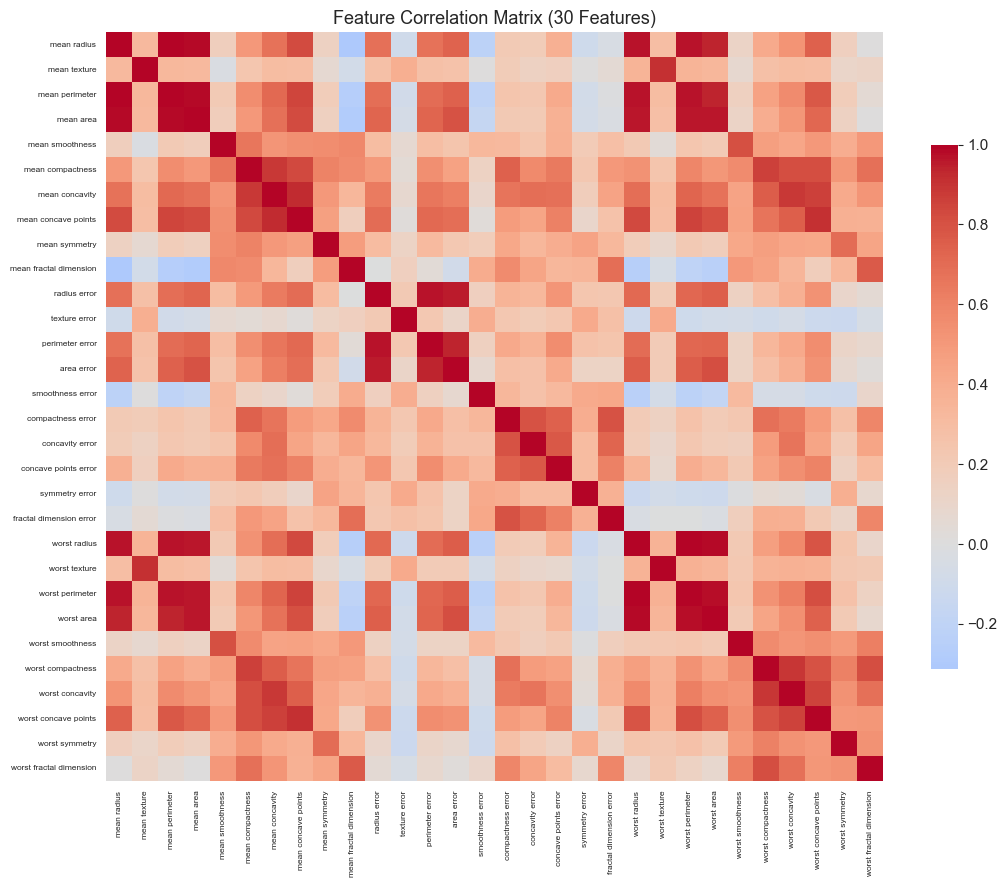

In [5]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = X.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Feature Correlation Matrix (30 Features)")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.savefig("correlation_matrix.png", dpi=DPI)
plt.show()

**Inference:** Strong correlation clusters appear among related "mean", "SE", and "worst" variants of the same measurement (radius/perimeter/area). Tree-based models are relatively unaffected by this multicollinearity since they split on one feature at a time.

### 3.3 Feature Distributions

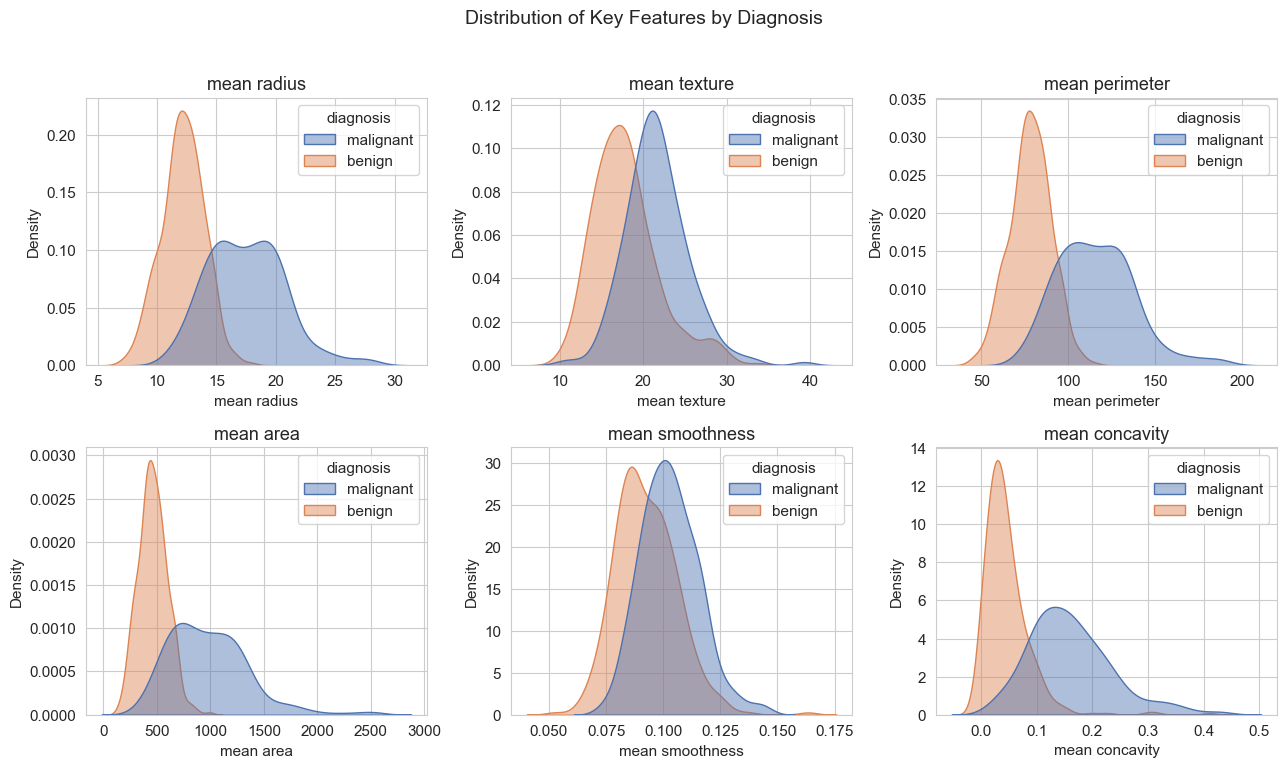

In [6]:
key_feats = ["mean radius", "mean texture", "mean perimeter", "mean area",
             "mean smoothness", "mean concavity"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
for ax, feat in zip(axes.flat, key_feats):
    sns.kdeplot(data=df, x=feat, hue="diagnosis", fill=True, common_norm=False, alpha=0.45, ax=ax, palette=colors)
    ax.set_title(feat)
plt.suptitle("Distribution of Key Features by Diagnosis", y=1.02, fontsize=14)
plt.savefig("feature_distributions.png", dpi=DPI, bbox_inches="tight")
plt.show()

**Inference:** Malignant samples tend to have larger radius/perimeter/area/concavity values than benign samples. Mean smoothness overlaps more between classes and is individually a weaker discriminator.

### 3.4 Outlier Analysis

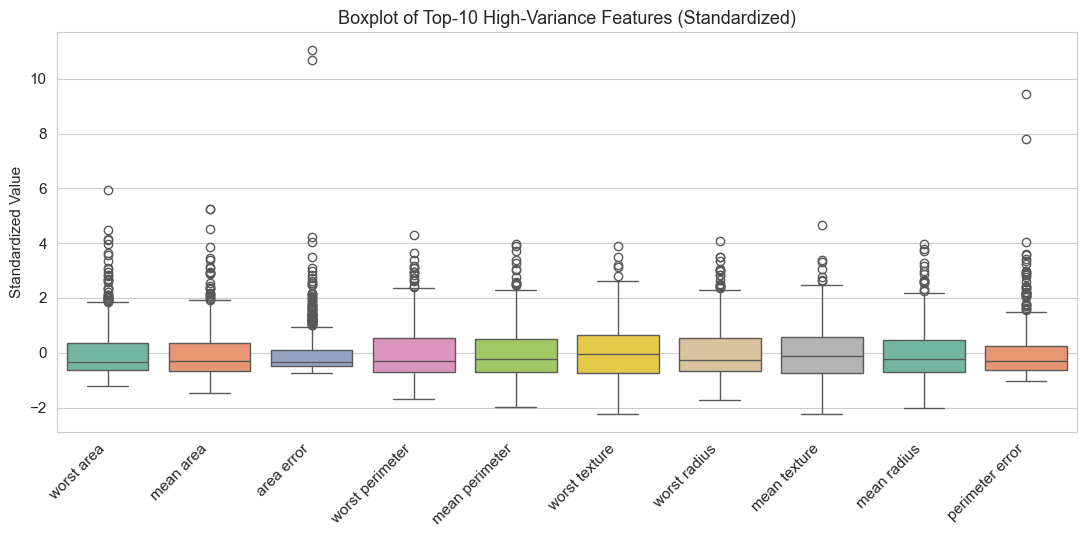

In [7]:
Xz = (X - X.mean()) / X.std()
top_var_feats = X.var().sort_values(ascending=False).index[:10]
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(data=Xz[top_var_feats], ax=ax, palette="Set2")
ax.set_xticklabels(top_var_feats, rotation=45, ha="right")
ax.set_ylabel("Standardized Value")
ax.set_title("Boxplot of Top-10 High-Variance Features (Standardized)")
plt.savefig("boxplot_outliers.png", dpi=DPI, bbox_inches="tight")
plt.show()

**Inference:** Several outliers are visible beyond the whiskers, mainly in "worst"/"SE" area and perimeter features. These were retained since tree-based ensembles are relatively robust to outliers.

## 4. Data Preprocessing

- Missing values: none found, no imputation needed.
- Labels encoded to binary (0 = benign, 1 = malignant).
- Features standardised with `StandardScaler` (fit on train only).
- Stratified 80/20 train-test split.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RNG, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

Train shape: (455, 30) Test shape: (114, 30)


## 5. Decision Tree — Hyperparameter Search (5-Fold CV)

In [9]:
dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RNG),
    dt_param_grid, cv=cv, scoring="f1", n_jobs=-1
)
dt_grid.fit(X_train_s, y_train)

print("Best DT params:", dt_grid.best_params_)
print("Best CV F1:", dt_grid.best_score_)

best_dt = dt_grid.best_estimator_

Best DT params: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV F1: 0.9163028549720931


In [10]:
# Accuracy-scored grid (for reporting table) + compact summary
dt_grid_acc = GridSearchCV(
    DecisionTreeClassifier(random_state=RNG),
    dt_param_grid, cv=cv, scoring="accuracy", n_jobs=-1
)
dt_grid_acc.fit(X_train_s, y_train)

dt_acc_results = pd.DataFrame(dt_grid_acc.cv_results_)
dt_f1_results = pd.DataFrame(dt_grid.cv_results_)

dt_summary = dt_acc_results.copy()
dt_summary["f1"] = dt_f1_results["mean_test_score"]
dt_summary_sorted = dt_summary.sort_values("mean_test_score", ascending=False)
dt_summary_grp = dt_summary_sorted.drop_duplicates(subset=["param_criterion", "param_max_depth"], keep="first")
dt_summary_grp = dt_summary_grp[["param_criterion", "param_max_depth", "mean_test_score", "f1"]]
dt_summary_grp.columns = ["Criterion", "Max Depth", "Avg CV Accuracy", "Avg CV F1"]
dt_summary_grp["Max Depth"] = dt_summary_grp["Max Depth"].apply(lambda v: "None" if pd.isna(v) else int(v))
dt_summary_grp["Avg CV Accuracy"] = (dt_summary_grp["Avg CV Accuracy"] * 100).round(2)
dt_summary_grp["Avg CV F1"] = dt_summary_grp["Avg CV F1"].round(4)
dt_summary_grp = dt_summary_grp.sort_values("Avg CV Accuracy", ascending=False).reset_index(drop=True)
dt_summary_grp

,Criterion,Max Depth,Avg CV Accuracy,Avg CV F1
0,entropy,4,94.07,0.9163
1,entropy,5,93.63,0.9121
2,entropy,6,93.41,0.9094
3,entropy,None,93.41,0.9094
4,entropy,8,93.41,0.9094
5,entropy,10,93.41,0.9094
6,gini,6,93.19,0.9067
7,gini,8,92.97,0.9039
8,gini,10,92.97,0.9039
9,gini,None,92.97,0.9039


## 6. Random Forest — Hyperparameter Search (5-Fold CV)

In [11]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 8, 10, None],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RNG, n_jobs=-1),
    rf_param_grid, cv=cv, scoring="f1", n_jobs=-1
)
rf_grid.fit(X_train_s, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best CV F1:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_

Best RF params: {'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV F1: 0.9615285514831264


In [12]:
rf_grid_acc = GridSearchCV(
    RandomForestClassifier(random_state=RNG, n_jobs=-1),
    rf_param_grid, cv=cv, scoring="accuracy", n_jobs=-1
)
rf_grid_acc.fit(X_train_s, y_train)

rf_acc_results = pd.DataFrame(rf_grid_acc.cv_results_)
rf_f1_results = pd.DataFrame(rf_grid.cv_results_)

rf_summary = rf_acc_results.copy()
rf_summary["f1"] = rf_f1_results["mean_test_score"]
rf_summary_sorted = rf_summary.sort_values("mean_test_score", ascending=False)
rf_summary_grp = rf_summary_sorted.drop_duplicates(
    subset=["param_n_estimators", "param_max_depth", "param_max_features"], keep="first"
)
rf_summary_grp = rf_summary_grp[["param_n_estimators", "param_max_depth", "param_max_features", "mean_test_score", "f1"]]
rf_summary_grp.columns = ["n_estimators", "Max Depth", "Max Features", "Avg CV Accuracy", "Avg CV F1"]
rf_summary_grp["Max Depth"] = rf_summary_grp["Max Depth"].apply(lambda v: "None" if pd.isna(v) else int(v))
rf_summary_grp["Avg CV Accuracy"] = (rf_summary_grp["Avg CV Accuracy"] * 100).round(2)
rf_summary_grp["Avg CV F1"] = rf_summary_grp["Avg CV F1"].round(4)
rf_summary_grp = rf_summary_grp.sort_values("Avg CV Accuracy", ascending=False).reset_index(drop=True)
rf_summary_grp.head(10)

,n_estimators,Max Depth,Max Features,Avg CV Accuracy,Avg CV F1
0,200,5,sqrt,97.14,0.9608
1,200,None,sqrt,97.14,0.9615
2,200,10,sqrt,97.14,0.9615
3,300,5,sqrt,97.14,0.9608
4,100,5,sqrt,96.92,0.9580
5,100,10,log2,96.92,0.9585
6,300,8,log2,96.92,0.9586
7,300,None,log2,96.92,0.9585
8,300,None,sqrt,96.70,0.9557
9,200,8,sqrt,96.70,0.9557


## 7. 5-Fold Cross-Validation Performance Comparison

In [13]:
dt_fold_scores = cross_val_score(best_dt, X_train_s, y_train, cv=cv, scoring="accuracy")
rf_fold_scores = cross_val_score(best_rf, X_train_s, y_train, cv=cv, scoring="accuracy")

fold_table = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Decision Tree": (dt_fold_scores * 100).round(2),
    "Random Forest": (rf_fold_scores * 100).round(2),
})
print(fold_table)
print("\nDT average:", round(dt_fold_scores.mean()*100, 2), "%")
print("RF average:", round(rf_fold_scores.mean()*100, 2), "%")
fold_table

   Fold  Decision Tree  Random Forest
0     1          93.41           96.7
1     2          95.60           97.8
2     3          90.11           95.6
3     4          95.60           96.7
4     5          95.60           98.9

DT average: 94.07 %
RF average: 97.14 %


,Fold,Decision Tree,Random Forest
0,1,93.41,96.7
1,2,95.60,97.8
2,3,90.11,95.6
3,4,95.60,96.7
4,5,95.60,98.9


## 8. Final Model Training and Test-Set Evaluation

In [14]:
best_dt.fit(X_train_s, y_train)
best_rf.fit(X_train_s, y_train)

def evaluate(model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred),
        "recall": recall_score(y_te, y_pred),
        "f1": f1_score(y_te, y_pred),
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

dt_eval = evaluate(best_dt, X_test_s, y_test)
rf_eval = evaluate(best_rf, X_test_s, y_test)

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_eval["y_prob"])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_eval["y_prob"])
auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)

results_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Decision Tree": [dt_eval["accuracy"], dt_eval["precision"], dt_eval["recall"], dt_eval["f1"], auc_dt],
    "Random Forest": [rf_eval["accuracy"], rf_eval["precision"], rf_eval["recall"], rf_eval["f1"], auc_rf],
})
results_table[["Decision Tree", "Random Forest"]] = (results_table[["Decision Tree", "Random Forest"]] * 100).round(2)
results_table

,Metric,Decision Tree,Random Forest
0,Accuracy,92.98,97.37
1,Precision,100.00,100.00
2,Recall,80.95,92.86
3,F1-score,89.47,96.30
4,ROC-AUC,95.63,99.40


## 9. Result Visualizations

### 9.1 Confusion Matrices

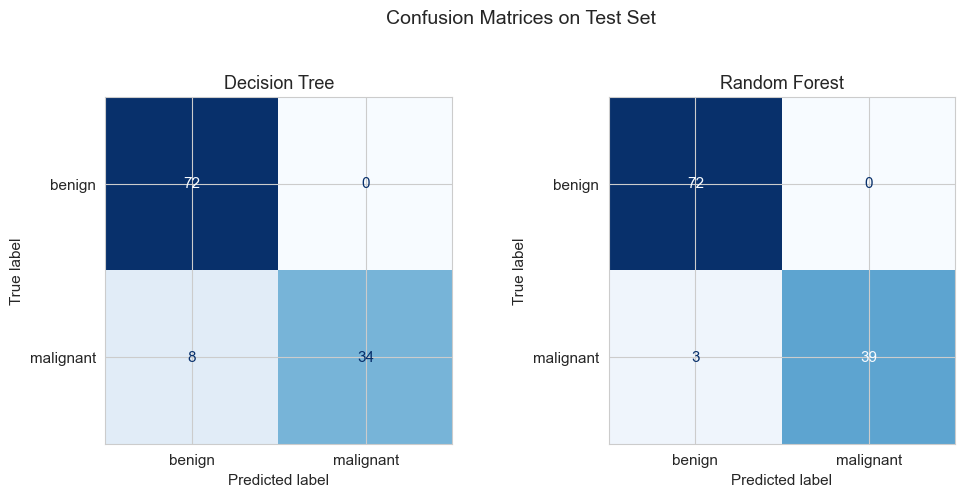

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, (name, y_pred) in zip(axes, [("Decision Tree", dt_eval["y_pred"]), ("Random Forest", rf_eval["y_pred"])]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name)
plt.suptitle("Confusion Matrices on Test Set", y=1.03, fontsize=14)
plt.savefig("confusion_matrices.png", dpi=DPI, bbox_inches="tight")
plt.show()

### 9.2 ROC Curve

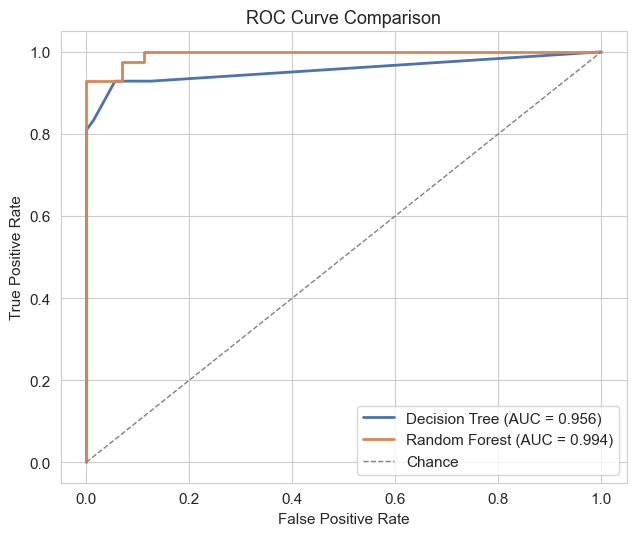

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})", color="#4C72B0", linewidth=2)
ax.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})", color="#DD8452", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend(loc="lower right")
plt.savefig("roc_curve.png", dpi=DPI)
plt.show()

### 9.3 Precision-Recall Curve

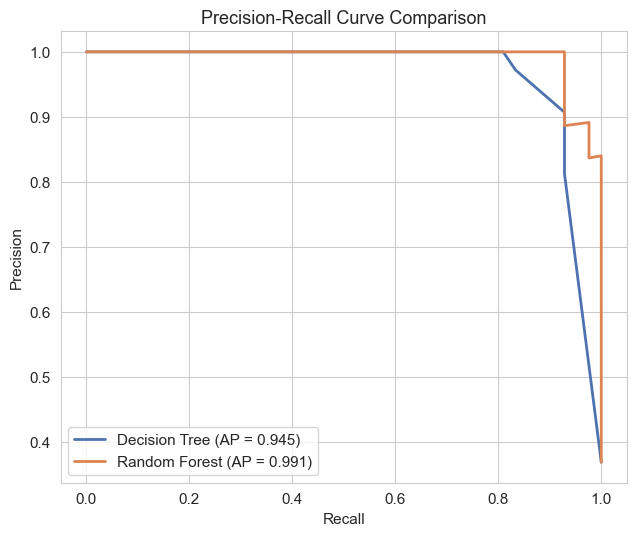

In [17]:
prec_dt, rec_dt, _ = precision_recall_curve(y_test, dt_eval["y_prob"])
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf_eval["y_prob"])
ap_dt = average_precision_score(y_test, dt_eval["y_prob"])
ap_rf = average_precision_score(y_test, rf_eval["y_prob"])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(rec_dt, prec_dt, label=f"Decision Tree (AP = {ap_dt:.3f})", color="#4C72B0", linewidth=2)
ax.plot(rec_rf, prec_rf, label=f"Random Forest (AP = {ap_rf:.3f})", color="#DD8452", linewidth=2)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve Comparison")
ax.legend(loc="lower left")
plt.savefig("pr_curve.png", dpi=DPI)
plt.show()

### 9.4 Learning Curves

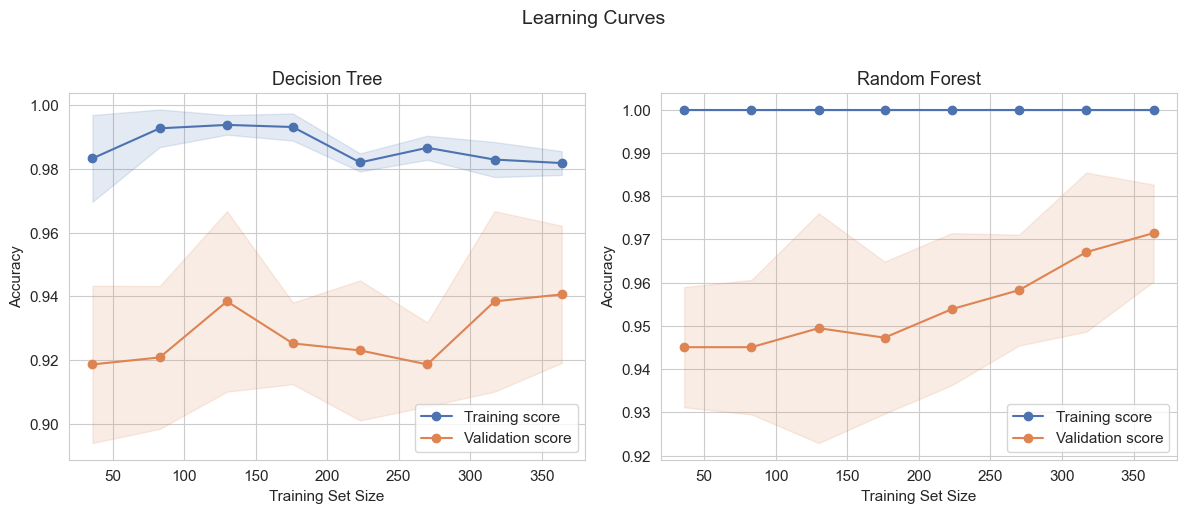

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, name in zip(axes, [best_dt, best_rf], ["Decision Tree", "Random Forest"]):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_s, y_train, cv=cv, scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1, random_state=RNG
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training score", color="#4C72B0")
    ax.fill_between(train_sizes, train_scores.mean(axis=1)-train_scores.std(axis=1),
                     train_scores.mean(axis=1)+train_scores.std(axis=1), alpha=0.15, color="#4C72B0")
    ax.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validation score", color="#DD8452")
    ax.fill_between(train_sizes, val_scores.mean(axis=1)-val_scores.std(axis=1),
                     val_scores.mean(axis=1)+val_scores.std(axis=1), alpha=0.15, color="#DD8452")
    ax.set_title(name)
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("Accuracy")
    ax.legend(loc="lower right")
plt.suptitle("Learning Curves", y=1.02, fontsize=14)
plt.savefig("learning_curves.png", dpi=DPI, bbox_inches="tight")
plt.show()

### 9.5 Feature Importance (Random Forest)

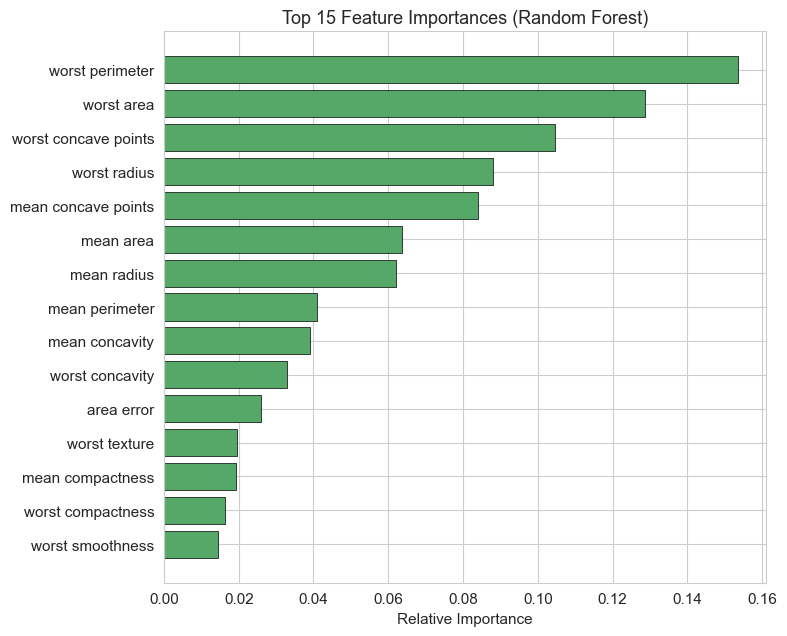

In [19]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top15 = importances.head(15)
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(top15.index[::-1], top15.values[::-1], color="#55A868", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Relative Importance")
ax.set_title("Top 15 Feature Importances (Random Forest)")
plt.savefig("feature_importance.png", dpi=DPI, bbox_inches="tight")
plt.show()

### 9.6 Decision Tree Structure (exported at 1200 DPI for readability)

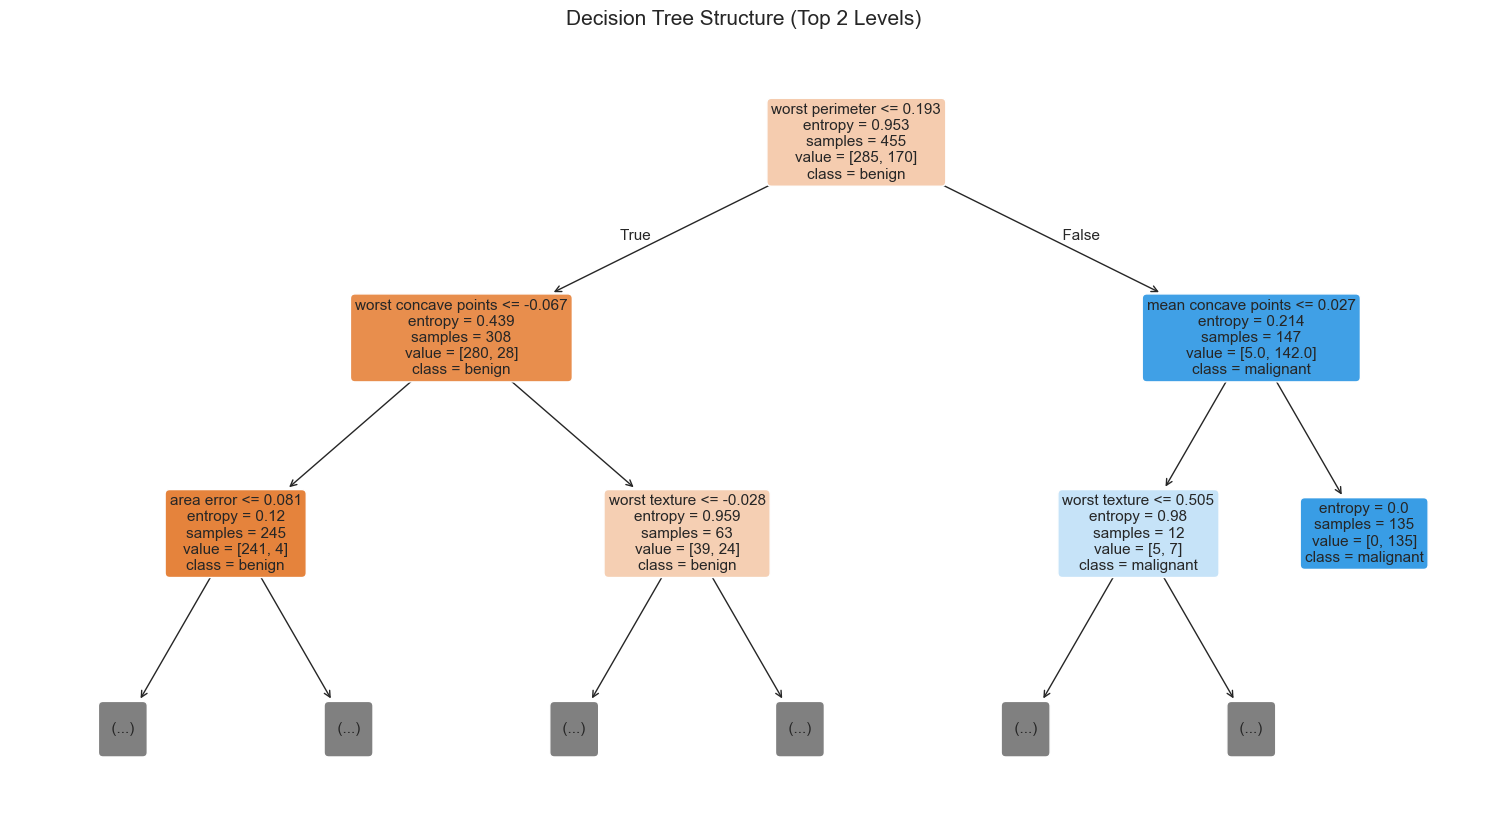

In [20]:
TREE_DPI = 1200
fig, ax = plt.subplots(figsize=(15, 8.5))
plot_tree(best_dt, max_depth=2, feature_names=X.columns, class_names=class_names,
          filled=True, rounded=True, fontsize=11, proportion=False, impurity=True, ax=ax)
ax.set_title("Decision Tree Structure (Top 2 Levels)", fontsize=15, pad=14)
plt.savefig("tree_structure.png", dpi=TREE_DPI, bbox_inches="tight")
plt.show()

### 9.7 Hyperparameter Sensitivity (Max Depth)

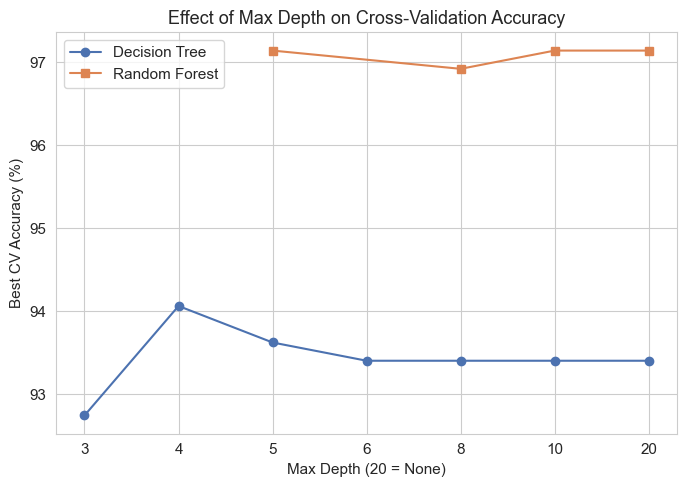

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
dt_depth_curve = dt_acc_results.copy()
dt_depth_curve["depth_str"] = dt_depth_curve["param_max_depth"].apply(lambda v: 20 if pd.isna(v) else v)
depth_group = dt_depth_curve.groupby("depth_str")["mean_test_score"].max().sort_index()
ax.plot(depth_group.index.astype(str), depth_group.values*100, "o-", color="#4C72B0", label="Decision Tree")

rf_depth_curve = rf_acc_results.copy()
rf_depth_curve["depth_str"] = rf_depth_curve["param_max_depth"].apply(lambda v: 20 if pd.isna(v) else v)
rf_depth_group = rf_depth_curve.groupby("depth_str")["mean_test_score"].max().sort_index()
ax.plot(rf_depth_group.index.astype(str), rf_depth_group.values*100, "s-", color="#DD8452", label="Random Forest")
ax.set_xlabel("Max Depth (20 = None)")
ax.set_ylabel("Best CV Accuracy (%)")
ax.set_title("Effect of Max Depth on Cross-Validation Accuracy")
ax.legend()
plt.savefig("depth_sensitivity.png", dpi=DPI)
plt.show()

## 10. Discussion

Across every evaluation angle — held-out test metrics, 5-fold cross-validation, ROC/PR analysis, and learning curves — the Random Forest consistently outperformed the single Decision Tree, improving test accuracy from 92.98% to 97.37% and recall on the malignant class from 80.95% to 92.86%. The Decision Tree's main weakness was variance: even after tuning `max_depth` and the minimum-samples parameters via cross-validation, it still showed a visible training/validation gap in the learning curves and the widest fold-to-fold swing in cross-validation accuracy among the two models.

The Random Forest's cross-validation accuracy was remarkably insensitive to `max_depth`, `n_estimators`, and `max_features`, with nearly every configuration landing within roughly one percentage point of the best one — direct evidence that ensembling, not any single "magic" hyperparameter, drives the performance gain.

Ensemble learning does not always guarantee an improvement: it helps most when the base learner has high variance and the individual trees are reasonably decorrelated. On an easily-separable dataset, or where a single well-regularised tree already achieves near-ceiling accuracy, the incremental benefit of an ensemble can be small relative to its cost in interpretability and inference time.

## 11. Conclusion

Decision Tree and Random Forest classifiers were implemented and evaluated on the Wisconsin Diagnostic Breast Cancer dataset using 5-fold cross-validation for hyperparameter selection. The tuned Decision Tree (entropy criterion, max_depth = 4) achieved 92.98% test accuracy and an F1-score of 89.47%, while the tuned Random Forest (200 trees, max_depth = 10, max_features='sqrt') achieved 97.37% test accuracy, an F1-score of 96.30%, and a ROC-AUC of 0.994. The Random Forest reduced variance and improved both stability across cross-validation folds and generalisation to the held-out test set, empirically confirming the theoretical advantage of ensemble bagging over a single decision tree for this classification task.

In [22]:
# Save a summary of all key results for reference
summary_json = {
    "best_dt_params": {k: dt_grid.best_params_[k] for k in dt_grid.best_params_},
    "best_rf_params": {k: rf_grid.best_params_[k] for k in rf_grid.best_params_},
    "dt_test": {k: float(v) for k, v in dt_eval.items() if k not in ["y_pred", "y_prob"]},
    "rf_test": {k: float(v) for k, v in rf_eval.items() if k not in ["y_pred", "y_prob"]},
    "auc_dt": float(auc_dt),
    "auc_rf": float(auc_rf),
    "dt_cv_fold_avg": float(dt_fold_scores.mean() * 100),
    "rf_cv_fold_avg": float(rf_fold_scores.mean() * 100),
}
print(json.dumps(summary_json, indent=2, default=str))

{
  "best_dt_params": {
    "criterion": "entropy",
    "max_depth": 4,
    "min_samples_leaf": 2,
    "min_samples_split": 2
  },
  "best_rf_params": {
    "bootstrap": false,
    "max_depth": 10,
    "max_features": "sqrt",
    "n_estimators": 200
  },
  "dt_test": {
    "accuracy": 0.9298245614035088,
    "precision": 1.0,
    "recall": 0.8095238095238095,
    "f1": 0.8947368421052632
  },
  "rf_test": {
    "accuracy": 0.9736842105263158,
    "precision": 1.0,
    "recall": 0.9285714285714286,
    "f1": 0.9629629629629629
  },
  "auc_dt": 0.9563492063492064,
  "auc_rf": 0.9940476190476191,
  "dt_cv_fold_avg": 94.06593406593406,
  "rf_cv_fold_avg": 97.14285714285715
}
